In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
df=pd.read_csv("wine_dataset.csv")
corr=df.corr()


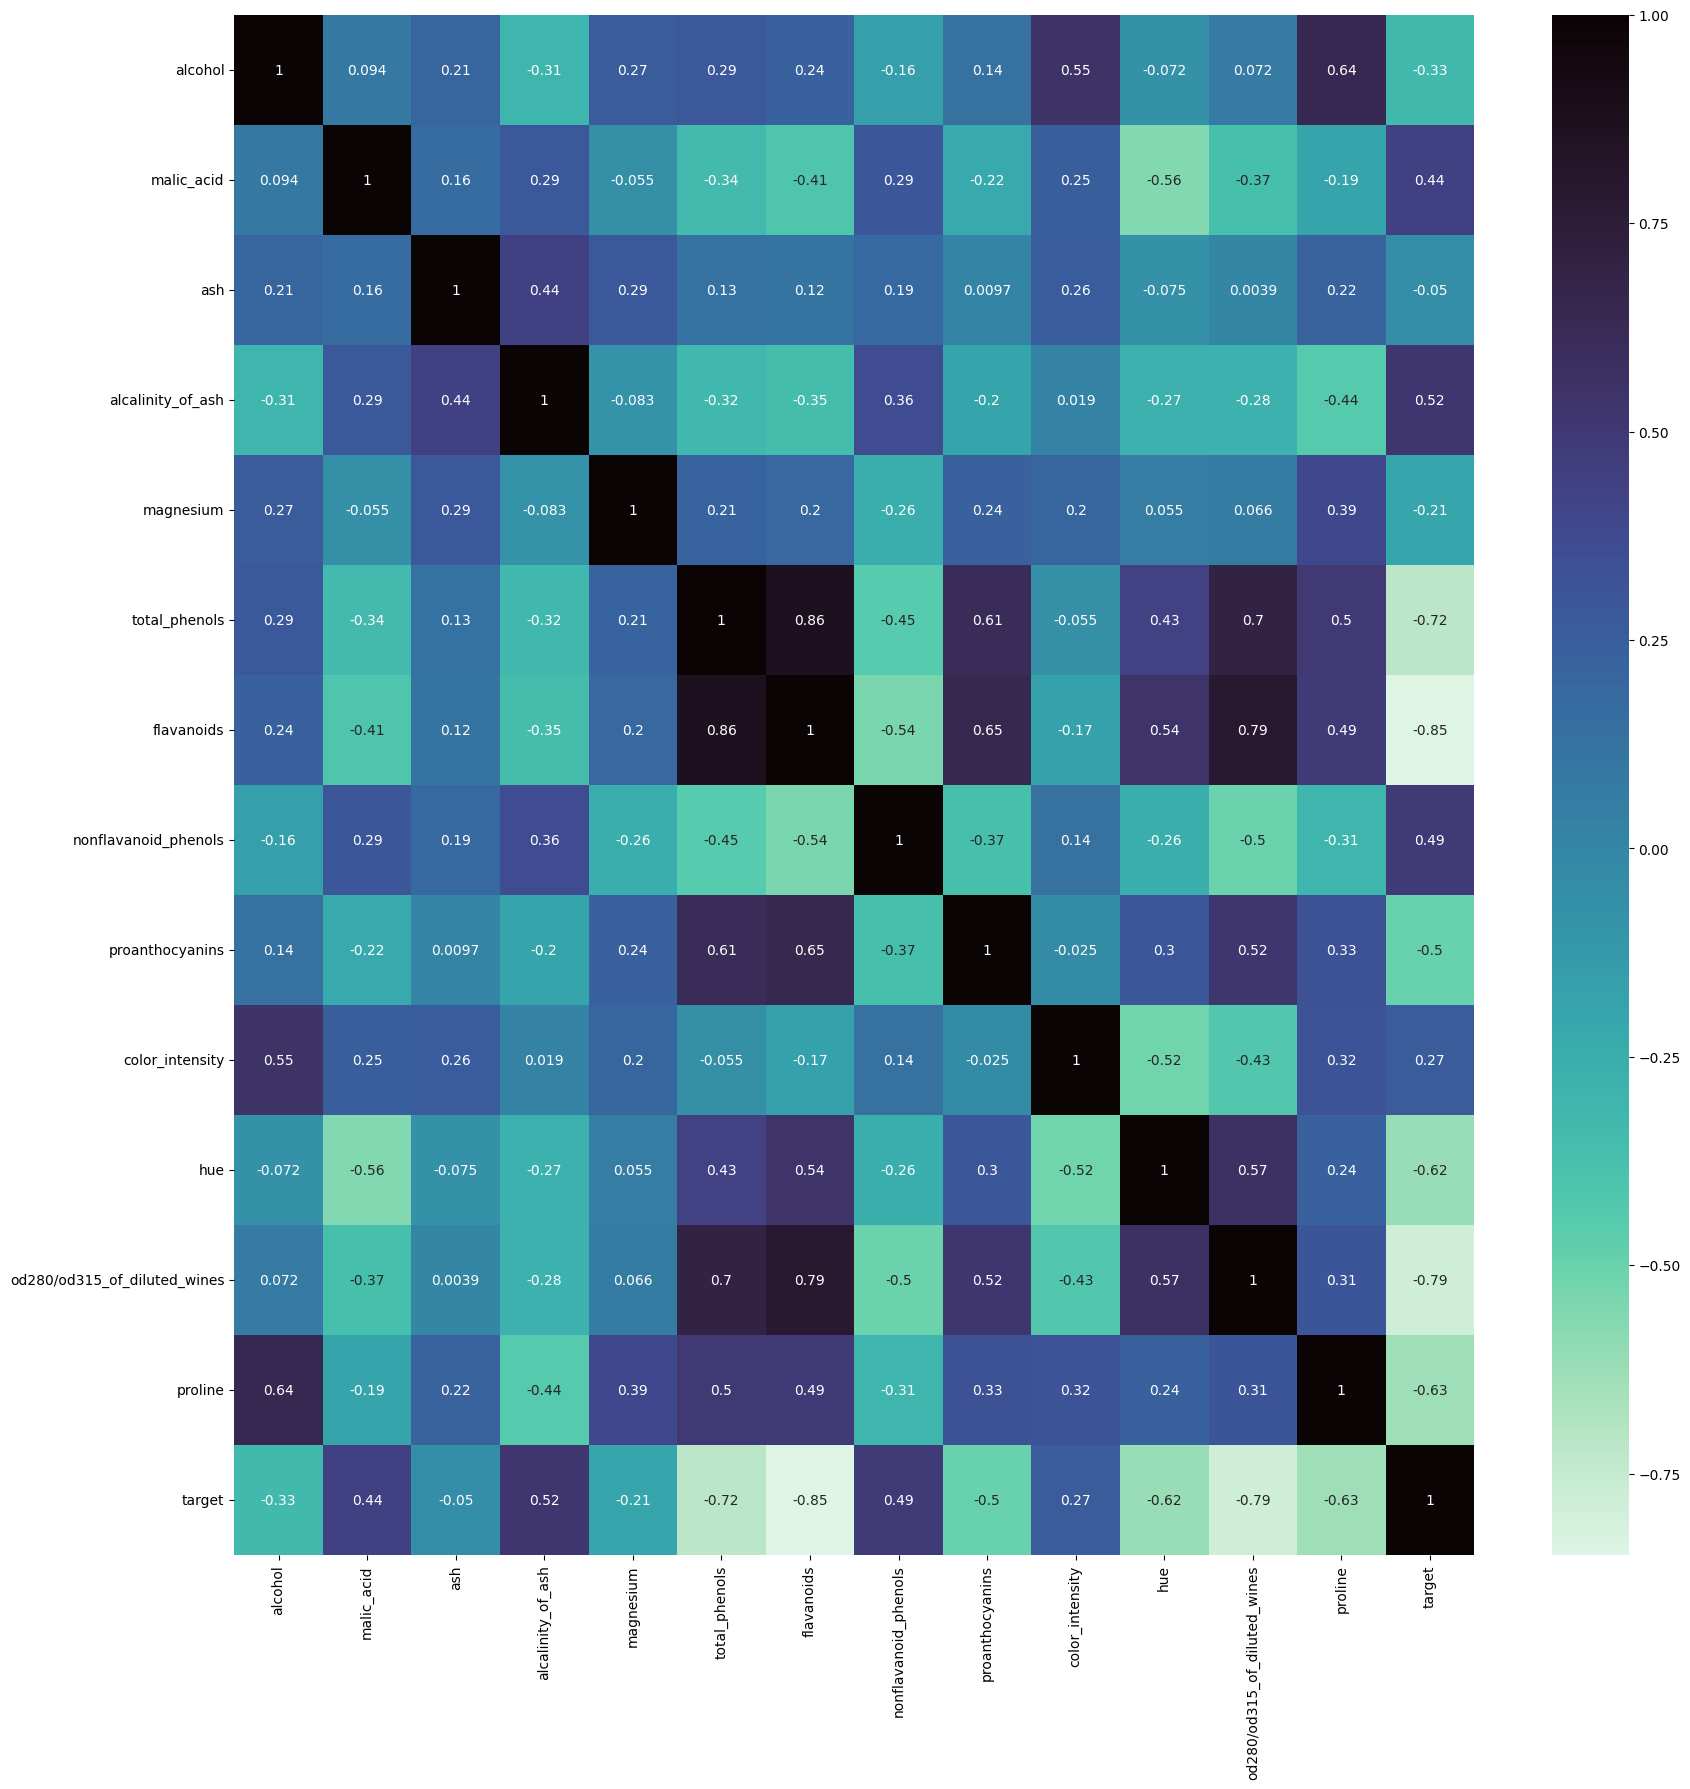

In [20]:
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='mako_r',annot=True)
plt.show()

In [21]:
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [22]:
req_cols=["alcalinity_of_ash","nonflavanoid_phenols", 'malic_acid']
x=np.array(df[req_cols])
X=df[req_cols]
y=df['target']
y.value_counts()


target
1    71
0    59
2    48
Name: count, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
X_test=scaler.transform(X_test)
X_train=scaler.transform(X_train)

In [45]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
y_pred=y_pred.round()
print(y_pred)
print(np.array(y_test))

[1. 1. 1. 1. 1. 1. 1. 2. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 1. 2.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 2. 0. 1. 0. 1. 0. 1. 2. 1. 1. 2.
 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1.]
[0 0 2 0 1 0 1 2 1 2 0 2 0 1 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 2 0 0 0 2
 2 1 2 0 1 1 1 2 0 1 1 2 0 1 0 0 2 2 1 1 0 1]


In [41]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error,r2_score

mse_value = mean_squared_error(y_test, y_pred)
rmse_value = root_mean_squared_error(y_test, y_pred)
r_squared_value = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse_value}")
print(f"Root Mean Squared Error (RMSE): {rmse_value}")
print(f"R-squared (Coefficient of Determination): {r_squared_value}")

Mean Squared Error (MSE): 0.3459952193710542
Root Mean Squared Error (RMSE): 0.5882135831235574
R-squared (Coefficient of Determination): 0.40960325557321575
